# Mall Customer Segmentation with K-Means

## Business use case

A retail or shopping-center team rarely gets the same value from treating every customer as one audience. Customers differ in age, purchasing power, and observed spending behavior, and those differences can shape how a retail team approaches campaigns, loyalty programs, and customer development.

This project uses unsupervised learning to turn those differences into a practical customer-segmentation view. The goal is not to predict an outcome, but to identify groups with similar profiles that can support more focused marketing and customer-management decisions.

## Principal objective

The notebook segments **200 customers** using three features: **Age**, **AnnualIncome**, and **SpendingScore**. K-Means is used to discover six behavioral-demographic groups, which are then examined through income, spending, age, and gender views.

The analysis is intentionally exploratory. The resulting clusters are useful as a starting point for customer strategy, but they should be validated with transactional and campaign-response data before being used for production targeting.

## Dataset at a glance

The sample contains customers between **18 and 70 years old**, with annual income values ranging from **15 to 137** and spending scores from **1 to 99**. The dataset includes **112 female and 88 male customers**.

`CustomerID` is retained as an identifier only. It is excluded from the clustering features because its numeric value does not describe customer behavior.

## Step 1 — Set up the analysis

The workflow starts by importing the libraries required for data manipulation, visualization, feature scaling, and K-Means clustering. The notebook also imports the silhouette score utility, although the saved analysis relies on the elbow method rather than a silhouette-based model-selection check.

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 2 — Load and profile the customer base

The first pass focuses on understanding the sample before creating any clusters. Descriptive statistics establish the range and central tendency of age, income, and spending score, while the gender count provides context on the composition of the dataset.

At this stage, the objective is to understand what the model will see and to separate meaningful customer attributes from administrative fields such as `CustomerID`.

In [ ]:
df = pd.read_csv('/data/SpendingScore.csv')
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
# Summary statistics
display(df.describe(include='all'))

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [ ]:
# Gender distribution
if 'Gender' in df.columns:
    print("\nGender counts:")
    print(df['Gender'].value_counts())


Gender counts:
Gender
Female    112
Male       88
Name: count, dtype: int64


## Step 3 — Explore relationships among customer variables

The exploratory analysis looks at correlations and feature distributions before clustering.

The strongest visible linear relationship is between **Age** and **SpendingScore**, with a correlation of approximately **-0.33**. In this sample, older customers tend to have lower spending scores. By contrast, annual income has almost no linear correlation with spending score, which is a useful reminder that purchasing behavior cannot be explained by income alone.

`CustomerID` shows a high correlation with annual income, but that reflects the ordering of this particular dataset rather than a meaningful customer characteristic. For that reason, it is not used as a clustering feature.

In [ ]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)
print("\nCorrelation (numeric):")
display(corr)




Correlation (numeric):


,CustomerID,Age,AnnualIncome,SpendingScore
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
AnnualIncome,0.977548,-0.012398,1.000000,0.009903
SpendingScore,0.013835,-0.327227,0.009903,1.000000


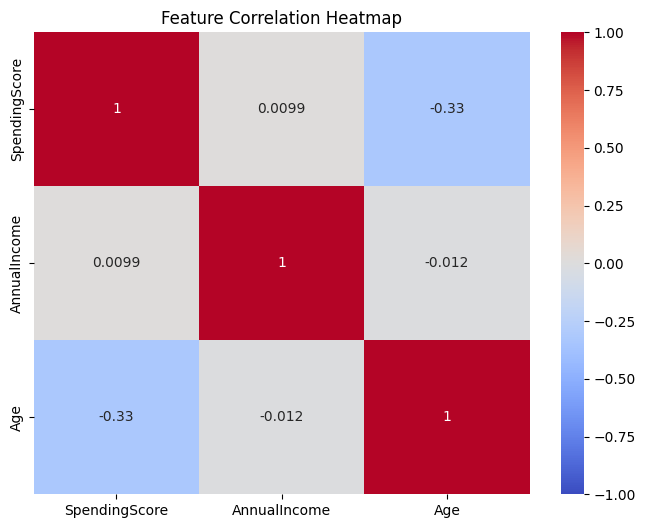

In [ ]:
plt.figure(figsize=(8, 6))
cols_of_interest = [c for c in ['SpendingScore','AnnualIncome','Age'] if c in num_df.columns]
# Heatmap using sns on cols_of_interest
sns.heatmap(num_df[cols_of_interest].corr(numeric_only=True),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Helpful peek focusing on spending-related variables
display(num_df[cols_of_interest].describe().T)


,count,mean,std,min,25%,50%,75%,max
SpendingScore,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0
AnnualIncome,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0


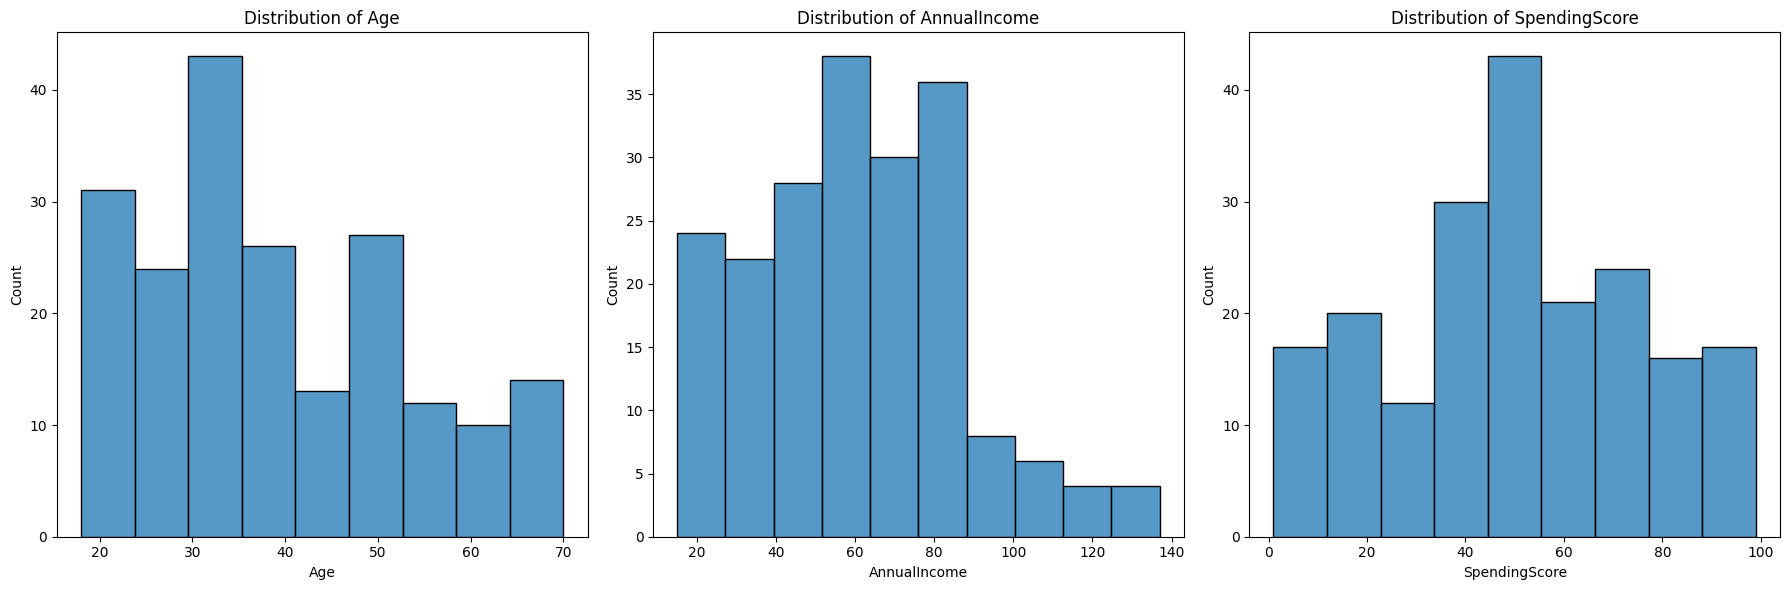

In [ ]:
plt.figure(figsize=(18, 6))
plot_number = 1

for col in ['Age', 'AnnualIncome', 'SpendingScore']:
    if plot_number <= 3:
        ax = plt.subplot(1, 3, plot_number)
        sns.histplot(df[col])
        plt.title(f'Distribution of {col}')
    plot_number += 1

plt.tight_layout()
plt.show()

## Step 4 — Prepare the features for clustering

Age bands are created for an additional demographic view, while the actual clustering uses **Age**, **AnnualIncome**, and **SpendingScore**.

These features operate on different numeric ranges, so they are standardized before fitting K-Means. This step is important because distance-based algorithms are sensitive to scale; without standardization, a feature with a wider numeric range can influence the cluster boundaries more heavily than intended.

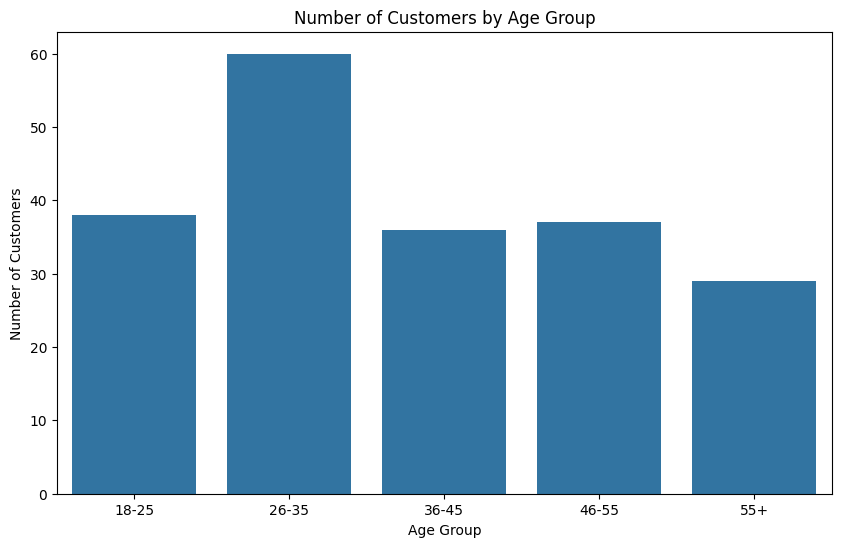

In [ ]:
# Define age bins
age_18_25 = df.Age[(df.Age >= 18) & (df.Age <= 25)]
age_26_35 = df.Age[(df.Age >= 26) & (df.Age <= 35)]
age_36_45 = df.Age[(df.Age >= 36) & (df.Age <= 45)]
age_46_55 = df.Age[(df.Age >= 46) & (df.Age <= 55)]
age_55above = df.Age[df.Age >= 56]

age_x = ["18-25","26-35","36-45","46-55","55+"]
age_y = [len(age_18_25.values),len(age_26_35.values),len(age_36_45.values),len(age_46_55.values),len(age_55above.values)]

plt.figure(figsize=(10,6))
sns.barplot(x=age_x, y=age_y)
plt.title("Number of Customers by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()


In [ ]:
# Select features available in this dataset
features = ["Age","AnnualIncome","SpendingScore"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(None if X_scaled is None else X_scaled.shape)

(200, 3)


## Step 5 — Choose the number of customer segments

The elbow method compares K-Means inertia across candidate values of `k`. The saved analysis selects **six clusters**, providing enough separation to reveal distinct combinations of age, income, and spending behavior without producing an overly fragmented segmentation.

This is a practical modeling choice rather than a definitive statistical optimum. For a production use case, I would complement the elbow curve with silhouette analysis, cluster-stability checks, and business validation to confirm that the six groups are both distinct and actionable.

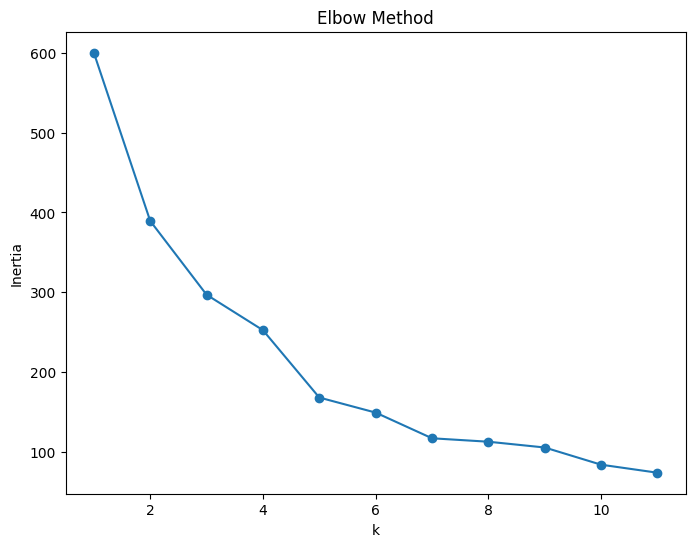

In [ ]:
inertias = []
for k in range(1,12):
  k_means = KMeans(n_clusters=k,random_state=0).fit(X_scaled)
  inertias.append(k_means.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 12), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.show()

## Step 6 — Fit K-Means and assign customer segments

K-Means is fitted on the standardized feature matrix using **six clusters**, `k-means++` initialization, a fixed random state, and multiple initializations.

Each customer receives a cluster label that is added back to the original dataframe. The labels themselves are arbitrary identifiers; the business meaning comes from profiling the age, income, and spending characteristics of the customers assigned to each group.

In [ ]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters,init='k-means++',random_state=42,n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans
print("DataFrame with Cluster Assignments:")
df.head()

DataFrame with Cluster Assignments:


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,5
3,4,Female,23,16,77,4
4,5,Female,31,17,40,5


## Step 7 — Profile the segments and translate them into business terms

The final visual analysis compares clusters across **income vs. spending**, **age vs. spending**, and **age vs. income**, followed by gender-specific views.

The supporting business review of the six-cluster solution describes the segments as follows:

| Cluster | Observed profile | Possible business interpretation |
|---|---|---|
| 0 | Older, average income, average spending | Stable mid-value customers who may respond to retention or convenience-focused offers |
| 1 | Younger, average income, average spending | Developing customers with room to increase engagement and basket size |
| 2 | Mostly older, high income, low spending | Customers with purchasing power but relatively low engagement; a strong group for reactivation testing |
| 3 | Younger, high income, high spending | High-value customers who are natural candidates for premium experiences and loyalty benefits |
| 4 | Younger, low income, high spending | Highly engaged customers who may be responsive to value-oriented promotions and rewards |
| 5 | Mostly older, low income, low spending | Lower-spend customers for whom broad acquisition or premium campaigns may be less efficient |

A broader pattern emerges across the groups: younger customers tend to show higher spending scores at both low and high income levels, while older customers at the income extremes tend to show lower spending scores. Customers around the middle-income range remain closer to average spending levels.

Gender is not used to create the clusters. It is examined afterward, and the same broad behavioral pattern remains visible for both male and female customers in this sample.

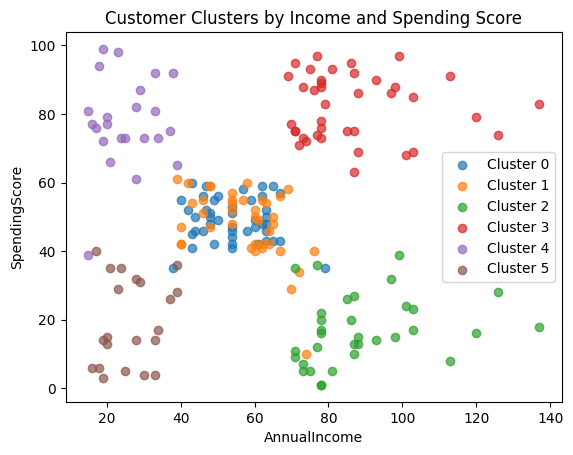

In [ ]:
x_col, y_col = 'AnnualIncome', 'SpendingScore'

plt.figure()
for c in sorted(df['Cluster'].unique()):
    _part = df[df['Cluster'] == c]
    plt.scatter(_part[x_col], _part[y_col],label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('Customer Clusters by Income and Spending Score')
plt.legend()
plt.show()


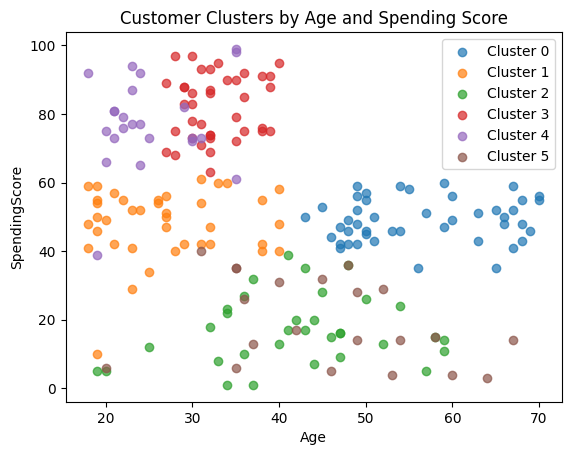

In [ ]:
x_col2, y_col2 = 'Age', 'SpendingScore'

plt.figure()

for c in sorted(df['Cluster'].unique()):
    _part = df[df['Cluster'] == c]
    plt.scatter(_part[x_col2], _part[y_col2], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col2)
plt.ylabel(y_col2)
plt.title('Customer Clusters by Age and Spending Score')
plt.legend()
plt.show()

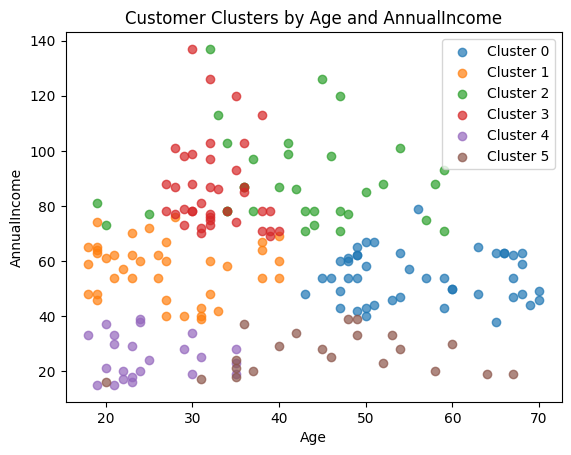

In [ ]:
x_col3, y_col3 = 'Age', 'AnnualIncome'

plt.figure()

for c in sorted(df['Cluster'].unique()):
    _part = df[df['Cluster'] == c]
    plt.scatter(_part[x_col3], _part[y_col3], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col3)
plt.ylabel(y_col3)
plt.title('Customer Clusters by Age and AnnualIncome')
plt.legend()
plt.show()

Gender   Female  Male
Cluster              
0            26    19
1            25    14
2            14    19
3            21    18
4            13    10
5            13     8


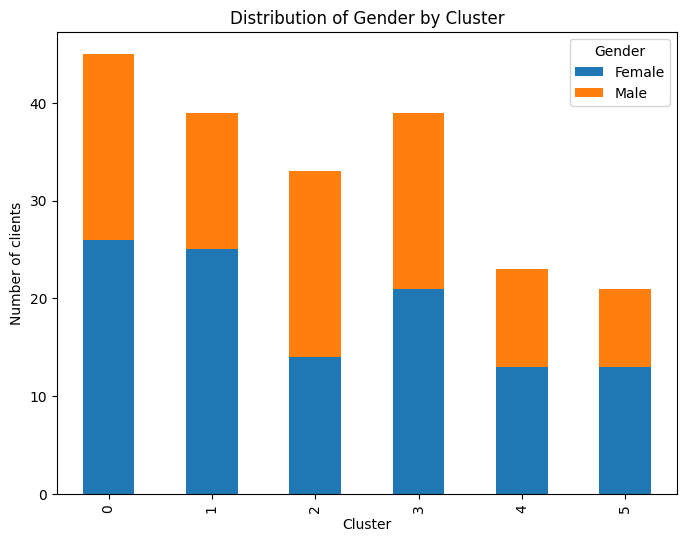

In [ ]:
gender_dist = pd.crosstab(df['Cluster'], df['Gender'])

print(gender_dist)

gender_dist.plot(kind='bar', stacked=True, figsize=(8,6))
plt.xlabel('Cluster')
plt.ylabel('Number of clients')
plt.title('Distribution of Gender by Cluster')
plt.legend(title='Gender')
plt.show()

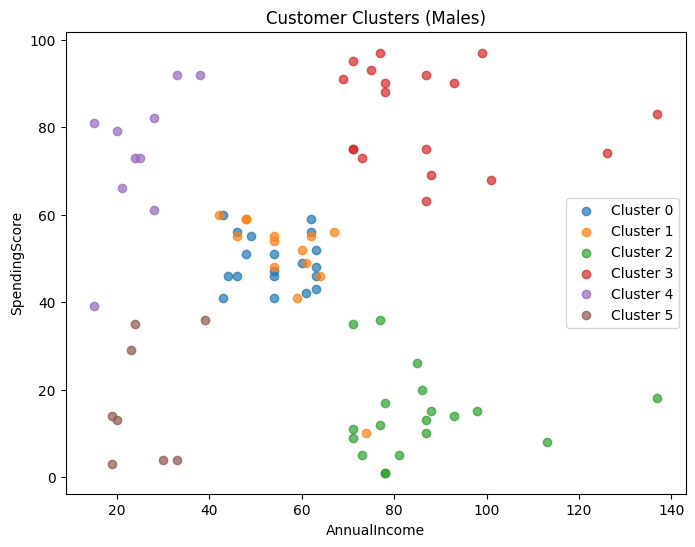

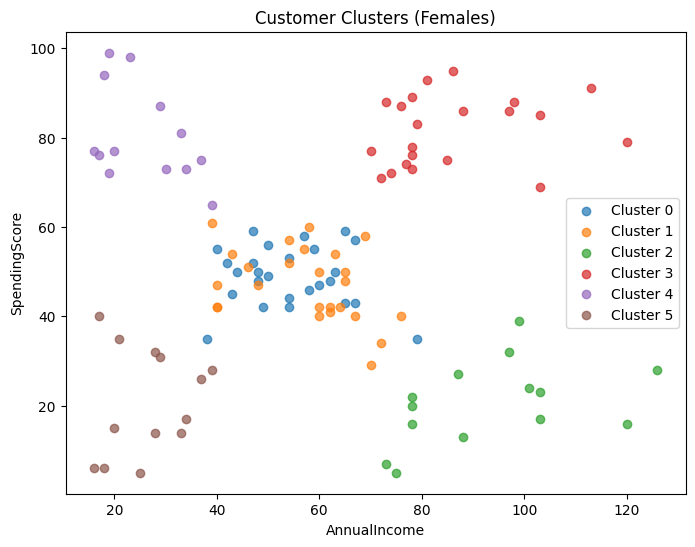

In [ ]:
# Males
plt.figure(figsize=(8,6))
df_male = df[df['Gender'] == 'Male']
for c in sorted(df_male['Cluster'].unique()):
    _part = df_male[df_male['Cluster'] == c]
    plt.scatter(_part[x_col], _part[y_col], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('Customer Clusters (Males)')
plt.legend()
plt.show()

# Females
plt.figure(figsize=(8,6))
df_female = df[df['Gender'] == 'Female']
for c in sorted(df_female['Cluster'].unique()):
    _part = df_female[df_female['Cluster'] == c]
    plt.scatter(_part[x_col], _part[y_col], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title('Customer Clusters (Females)')
plt.legend()
plt.show()

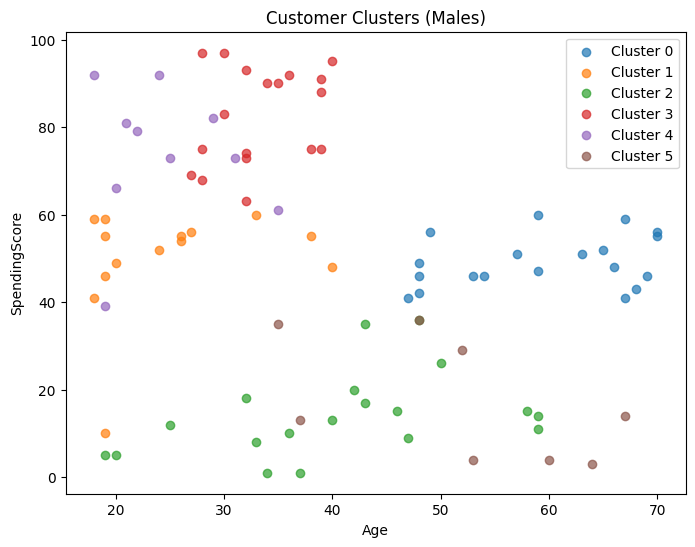

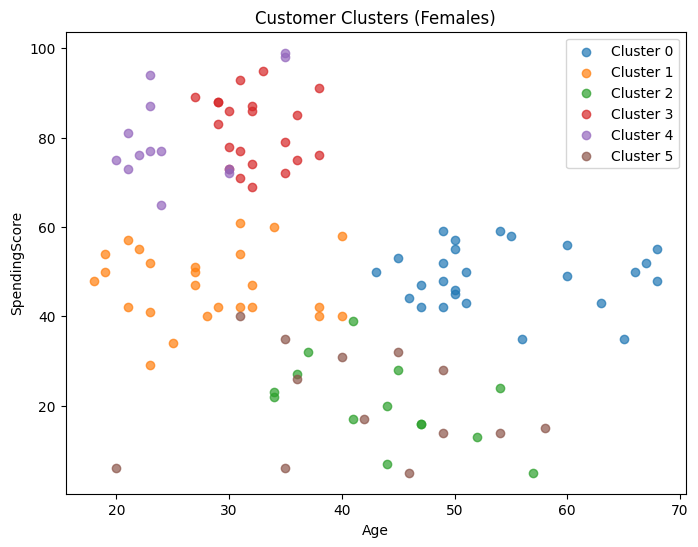

In [ ]:
# Males
plt.figure(figsize=(8,6))
df_male = df[df['Gender'] == 'Male']
for c in sorted(df_male['Cluster'].unique()):
    _part = df_male[df_male['Cluster'] == c]
    plt.scatter(_part[x_col2], _part[y_col2], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col2)
plt.ylabel(y_col2)
plt.title('Customer Clusters (Males)')
plt.legend()
plt.show()

# Females
plt.figure(figsize=(8,6))
df_female = df[df['Gender'] == 'Female']
for c in sorted(df_female['Cluster'].unique()):
    _part = df_female[df_female['Cluster'] == c]
    plt.scatter(_part[x_col2], _part[y_col2], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col2)
plt.ylabel(y_col2)
plt.title('Customer Clusters (Females)')
plt.legend()
plt.show()

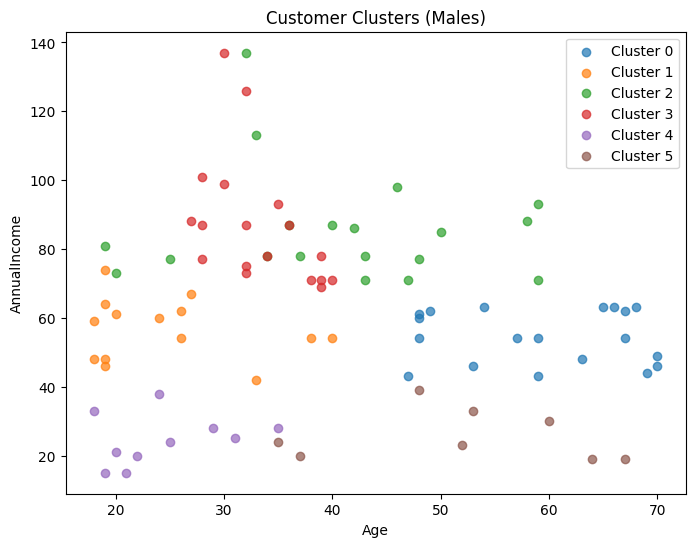

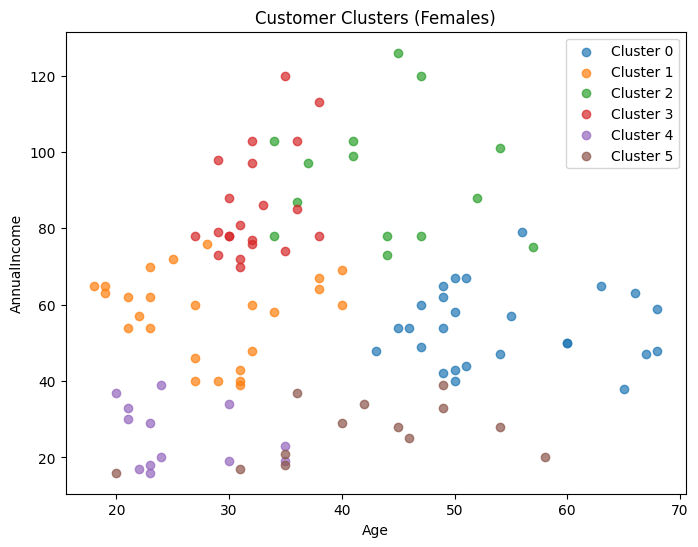

In [ ]:
# Males
plt.figure(figsize=(8,6))
df_male = df[df['Gender'] == 'Male']
for c in sorted(df_male['Cluster'].unique()):
    _part = df_male[df_male['Cluster'] == c]
    plt.scatter(_part[x_col3], _part[y_col3], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col3)
plt.ylabel(y_col3)
plt.title('Customer Clusters (Males)')
plt.legend()
plt.show()

# Females
plt.figure(figsize=(8,6))
df_female = df[df['Gender'] == 'Female']
for c in sorted(df_female['Cluster'].unique()):
    _part = df_female[df_female['Cluster'] == c]
    plt.scatter(_part[x_col3], _part[y_col3], label=f'Cluster {c}', alpha=0.7)
plt.xlabel(x_col3)
plt.ylabel(y_col3)
plt.title('Customer Clusters (Females)')
plt.legend()
plt.show()

## Technical conclusions

The notebook produces a six-cluster segmentation using standardized age, annual income, and spending-score features. Standardization is an appropriate choice for K-Means because the algorithm relies on Euclidean distance and the original variables are measured on different scales.

The segmentation is descriptive rather than predictive. It shows that age, income, and spending behavior can form useful customer groups even when pairwise correlations are weak. In particular, annual income alone does not explain spending score, yet the combination of income, age, and spending creates distinct profiles.

There are also several points I would strengthen before moving this workflow into production:

- Validate the choice of six clusters with silhouette score and repeated stability tests.
- Build a cluster-profile table with medians, distributions, and segment sizes rather than relying only on scatter plots.
- Track cluster stability over time and monitor whether customers migrate between segments.
- Treat cluster labels as model outputs, not permanent customer identities.
- Keep identifiers such as `CustomerID` outside the feature set even when they appear correlated with business variables.

## Business conclusions

The segmentation creates a useful starting point for differentiated customer strategy. The clearest opportunities are not simply “high income” or “low income” groups, but combinations of purchasing power and actual engagement.

The younger, high-income, high-spending segment is a natural candidate for testing premium loyalty experiences. The older, high-income, low-spending group is an interesting re-engagement audience because its income profile is not reflected in its spending score. Younger customers with lower income but high spending are also worth testing with value-led rewards and promotions.

The gender analysis suggests that the broad age-income-spending pattern is present for both genders in this dataset. That makes gender more useful as a secondary profiling variable than as the primary basis for the segmentation.

## Limitations and next steps

The dataset contains only **200 customers** and three behavioral-demographic clustering features, so the segments should be treated as exploratory. The next iteration would benefit from variables that capture what customers actually do over time, such as:

- customer tenure or time in the loyalty program,
- visit frequency and recency,
- transaction value and purchase frequency,
- product or category preferences,
- promotion response,
- digital engagement,
- churn or inactivity indicators.

With richer behavioral data, the segmentation could move from a static demographic snapshot toward a more actionable customer-lifecycle model. The most important business validation would then be whether the segments show measurable differences in campaign response, retention, or revenue—not only whether they look distinct on a chart.